# Exploratory Data Analysis

## 0. Imports and load

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_csv(r"C:\Users\kumri\Downloads\Data Science Notebooks\Product Sales\sales_clean.csv")
print('Shape:',df.shape)
print(df.dtypes)
df.head()

Shape: (200000, 14)
order_id           int64
order_date        object
customer_name     object
city              object
state             object
region            object
country           object
category          object
sub_category      object
product_name      object
quantity           int64
unit_price       float64
revenue          float64
profit           float64
dtype: object


,order_id,order_date,customer_name,city,state,region,country,category,sub_category,product_name,quantity,unit_price,revenue,profit
0,1,2023-08-23,Bianca Brown,Jackson,Mississippi,South,United States,Accessories,Small Electronics,Phone Case,3,201.01,603.03,221.49
1,2,2024-12-20,Jared Edwards,Grand Rapids,Michigan,Centre,United States,Accessories,Small Electronics,Charging Cable,4,74.30,297.20,97.09
2,3,2024-01-29,Susan Valdez,Minneapolis,Minnesota,Centre,United States,Clothing & Apparel,Sportswear,Nike Air Force 1,1,68.19,68.19,25.47
3,4,2024-11-29,Tina Williams,Tallahassee,Florida,South,United States,Clothing & Apparel,Sportswear,Adidas Tracksuit,3,209.64,628.92,231.38
4,5,2023-09-21,Catherine Gordon,Baltimore,Maryland,East,United States,Accessories,Bags,Backpack,1,216.63,216.63,42.46


## 1. Data cleaning

In [2]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.strftime('%b')
df['year_month'] = df['order_date'].dt.to_period('M')

print('order_date:', df['order_date'].dtypes)
df[['order_date', 'year', 'month', 'month_name', 'year_month']].head()

order_date: datetime64[ns]


,order_date,year,month,month_name,year_month
0,2023-08-23,2023,8,Aug,2023-08
1,2024-12-20,2024,12,Dec,2024-12
2,2024-01-29,2024,1,Jan,2024-01
3,2024-11-29,2024,11,Nov,2024-11
4,2023-09-21,2023,9,Sep,2023-09


In [3]:
df['margin_profit'] = (df['profit']/df['revenue'] * 100).round(2)
print('Duplicados:',df.duplicated().sum())
print('Null values:',df.isnull().sum()[df.isnull().sum()>0])

Duplicados: 0
Null values: Series([], dtype: int64)


In [4]:
df[['quantity', 'unit_price', 'revenue', 'profit', 'margin_profit']].describe().round(2)

,quantity,unit_price,revenue,profit,margin_profit
count,200000.00,200000.00,200000.00,200000.00,200000.00
mean,1.85,382.86,712.04,157.74,25.77
std,1.10,276.87,742.47,155.69,10.44
min,1.00,17.03,17.03,3.92,8.00
25%,1.00,162.76,229.19,59.21,17.12
50%,1.00,303.54,464.88,109.53,24.99
75%,2.00,562.25,881.30,199.40,33.59
max,11.00,1432.00,9014.25,2763.72,50.00


In [5]:
Q1 = df['revenue'].quantile(0.25)
Q3 = df['revenue'].quantile(0.75)
IQR = Q3-Q1

outliers = df[df['revenue'] > Q3 + 1.5 * IQR]
print(f'Outliers in revenue: {len(outliers):,} lines ({len(outliers)/len(df) * 100:.1f}%)')

Outliers in revenue: 15,068 lines (7.5%)


## 2. Profit margin distribution

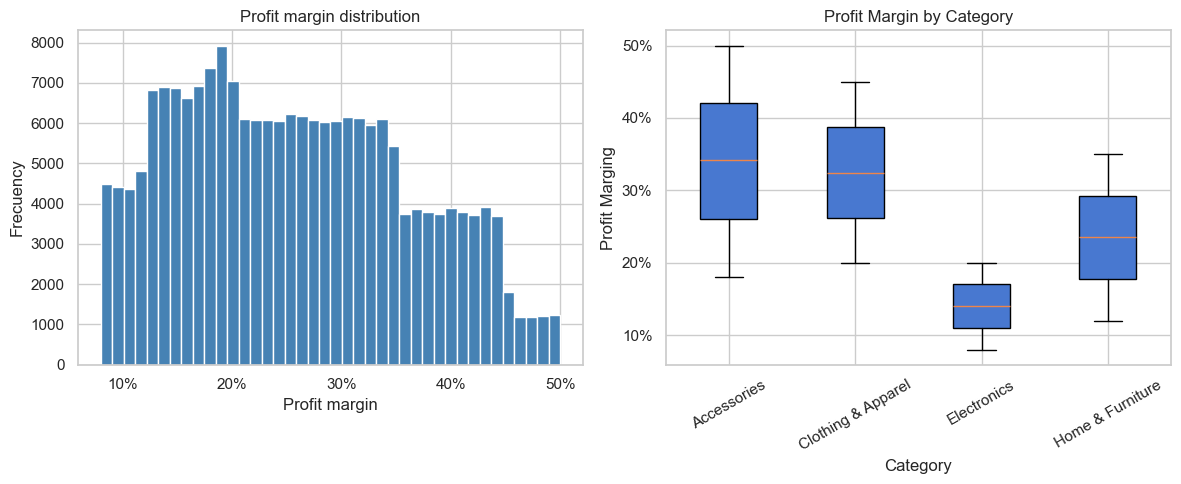

In [6]:
fig, axes = plt.subplots(1,2,figsize=(12,5))

#Histplots
axes[0].hist(df['margin_profit'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Profit margin distribution')
axes[0].set_xlabel('Profit margin')
axes[0].set_ylabel('Frecuency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))

#Boxplots
categories = df['category'].unique()
data_by_cat = [df[df['category'] == c]['margin_profit'] for c in categories]
axes[1].boxplot(data_by_cat, tick_labels=categories, patch_artist=True)
axes[1].set_title('Profit Margin by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Profit Marging')
axes[1].tick_params(axis='x',rotation=30)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))

plt.tight_layout()
plt.savefig(r'C:\Users\kumri\Downloads\Data Science Notebooks\Product Sales\exports\Profit Margin')
plt.show()

## 3. Monthly sales between 2023-2024

In [7]:
df.head()

,order_id,order_date,customer_name,city,state,region,country,category,sub_category,product_name,quantity,unit_price,revenue,profit,year,month,month_name,year_month,margin_profit
0,1,2023-08-23,Bianca Brown,Jackson,Mississippi,South,United States,Accessories,Small Electronics,Phone Case,3,201.01,603.03,221.49,2023,8,Aug,2023-08,36.73
1,2,2024-12-20,Jared Edwards,Grand Rapids,Michigan,Centre,United States,Accessories,Small Electronics,Charging Cable,4,74.30,297.20,97.09,2024,12,Dec,2024-12,32.67
2,3,2024-01-29,Susan Valdez,Minneapolis,Minnesota,Centre,United States,Clothing & Apparel,Sportswear,Nike Air Force 1,1,68.19,68.19,25.47,2024,1,Jan,2024-01,37.35
3,4,2024-11-29,Tina Williams,Tallahassee,Florida,South,United States,Clothing & Apparel,Sportswear,Adidas Tracksuit,3,209.64,628.92,231.38,2024,11,Nov,2024-11,36.79
4,5,2023-09-21,Catherine Gordon,Baltimore,Maryland,East,United States,Accessories,Bags,Backpack,1,216.63,216.63,42.46,2023,9,Sep,2023-09,19.60


In [8]:
month_name=df['month_name'].unique().tolist()
month_name

['Aug',
 'Dec',
 'Jan',
 'Nov',
 'Sep',
 'Oct',
 'May',
 'Jun',
 'Jul',
 'Feb',
 'Mar',
 'Apr']

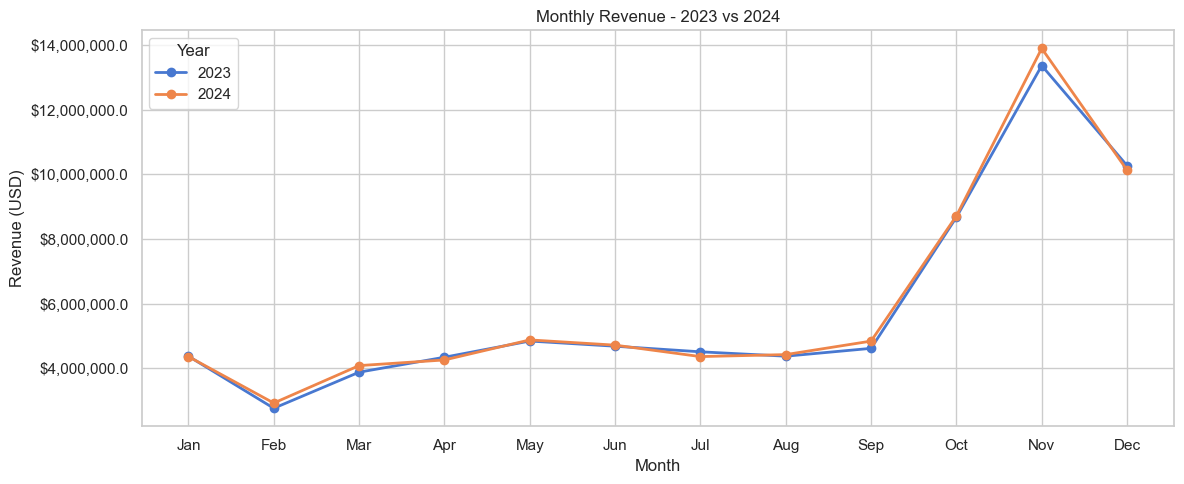

In [9]:
monthly = (df.groupby(['year','month','month_name'])['revenue']
    .sum()
    .reset_index()
    .sort_values(['year','month'])
          )

fig, ax = plt.subplots(figsize=(12,5))

for year, group in monthly.groupby('year'):
    ax.plot(group['month'], group['revenue'], marker='o', label=str(year), linewidth=2)

ax.set_title('Monthly Revenue - 2023 vs 2024')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (USD)')
ax.set_xticks(range(1,13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,}'))
ax.legend(title='Year')

plt.tight_layout()
plt.savefig(r'C:\Users\kumri\Downloads\Data Science Notebooks\Product Sales\exports\Monthly Revenue')
plt.show()

## 4. Top 10 products by revenue

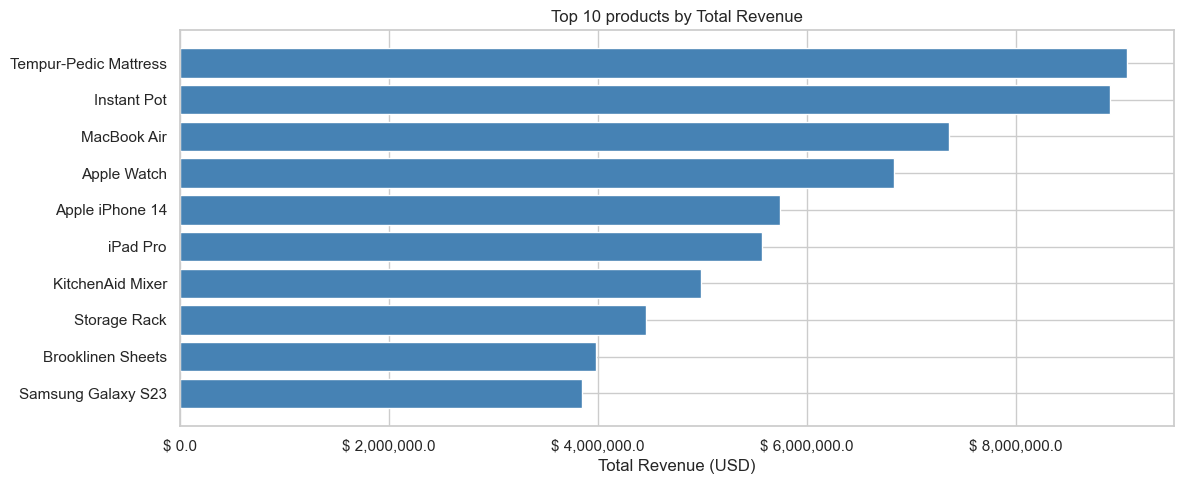

In [10]:
top10 = (
    df.groupby('product_name')
    .agg(
        total_revenue = ('revenue','sum'),
        total_profit = ('profit','sum'),
        units_sold = ('quantity', 'sum')
    )
    .assign(profit_margin = lambda x: (x['total_profit']/x['total_revenue'] * 100).round(1))
    .sort_values('total_revenue', ascending = False)
    .head(10)
    .reset_index()
)

fig ,ax = plt.subplots(figsize = (12,5))
ax.barh(top10['product_name'], 
        top10['total_revenue'],
        color='steelblue',
        edgecolor='white')

ax.invert_yaxis()
ax.set_title('Top 10 products by Total Revenue')
ax.set_xlabel('Total Revenue (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'$ {x:,}'))
plt.tight_layout()
plt.savefig(r'C:\Users\kumri\Downloads\Data Science Notebooks\Product Sales\exports\Top 10 products by Revenue')
plt.show()

## 5. Revenue and margin profit by Region

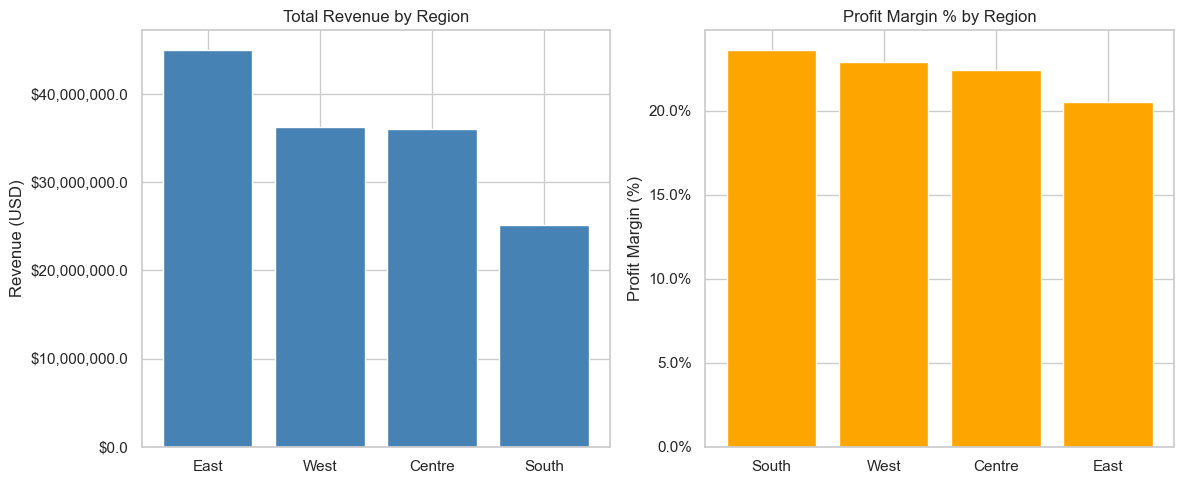

In [11]:
region_summary=(
    df.groupby('region')
    .agg(
        total_revenue = ('revenue', 'sum'),
        total_profit = ('profit','sum'),
        transactions = ('order_id','count')
    )
    .assign(profit_margin = lambda x: (x['total_profit']/x['total_revenue'] * 100).round(1))
    .sort_values('total_revenue', ascending = False)
    .reset_index()
)

fig, axes = plt.subplots(1,2,figsize=(12,5))

#Revenue by region
axes[0].bar(region_summary['region'], region_summary['total_revenue'], color='steelblue')
axes[0].set_title('Total Revenue by Region')
axes[0].set_ylabel('Revenue (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,}')) 

margin_sorted = region_summary.sort_values('profit_margin', ascending=False)
#Margin by region
axes[1].bar(margin_sorted['region'], margin_sorted['profit_margin'], color='orange')
axes[1].set_title('Profit Margin % by Region')
axes[1].set_ylabel('Profit Margin (%)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.1f}%'))

plt.tight_layout()
plt.savefig(r'C:\Users\kumri\Downloads\Data Science Notebooks\Product Sales\exports\Revenue & Profit by Region')
plt.show()

## Export for Power BI    

In [12]:
df.head()

,order_id,order_date,customer_name,city,state,region,country,category,sub_category,product_name,quantity,unit_price,revenue,profit,year,month,month_name,year_month,margin_profit
0,1,2023-08-23,Bianca Brown,Jackson,Mississippi,South,United States,Accessories,Small Electronics,Phone Case,3,201.01,603.03,221.49,2023,8,Aug,2023-08,36.73
1,2,2024-12-20,Jared Edwards,Grand Rapids,Michigan,Centre,United States,Accessories,Small Electronics,Charging Cable,4,74.30,297.20,97.09,2024,12,Dec,2024-12,32.67
2,3,2024-01-29,Susan Valdez,Minneapolis,Minnesota,Centre,United States,Clothing & Apparel,Sportswear,Nike Air Force 1,1,68.19,68.19,25.47,2024,1,Jan,2024-01,37.35
3,4,2024-11-29,Tina Williams,Tallahassee,Florida,South,United States,Clothing & Apparel,Sportswear,Adidas Tracksuit,3,209.64,628.92,231.38,2024,11,Nov,2024-11,36.79
4,5,2023-09-21,Catherine Gordon,Baltimore,Maryland,East,United States,Accessories,Bags,Backpack,1,216.63,216.63,42.46,2023,9,Sep,2023-09,19.60


In [13]:
#CSV connected to Power BI
df.to_csv(r'C:\Users\kumri\Downloads\Data Science Notebooks\Product Sales\exports\sales_final.csv',
         index=False)

#Forecasting
monthly_bi = (
    df.groupby('year_month')
    .agg(
        monthly_revenue = ('revenue', 'sum'),
        monthly_profit = ('profit', 'sum')
    )
    .reset_index()
)
monthly_bi['year_month'] = monthly_bi['year_month'].astype(str)
monthly_bi.to_csv(r'C:\Users\kumri\Downloads\Data Science Notebooks\Product Sales\exports\monthly_timeseries.csv',
                 index=False)

print('Exports done')


Exports done
